# RAG Part 3: Vector Store
## Build an Economics Study Buddy from a Real Textbook

In Parts 1 and 2, we used 5 hardcoded sentences. Now we'll build something real: **a study tool that searches an entire economics textbook to answer your questions.**

Our knowledge base is [Principles of Microeconomics 3e](https://openstax.org/details/books/principles-microeconomics-3e) from OpenStax — every answer is grounded in actual textbook content.

---
## Setup

In [25]:
%pip install datasets onnxruntime transformers huggingface_hub --break-system-packages

import matplotlib.pyplot as plt
import numpy as np
import os
import onnxruntime as ort

from datasets import load_dataset
from huggingface_hub import hf_hub_download
from matplotlib.patches import Patch
from transformers import AutoTokenizer

try:
    from llama_cpp import Llama
except ImportError:
    %pip install llama-cpp-python --break-system-packages
    from llama_cpp import Llama

# Download the quantized ONNX embedding model (~23MB, much smaller than the full 90MB)
onnx_path = hf_hub_download(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    filename="onnx/model_O4.onnx",
)
onnx_session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def encode(texts):
    """Encode texts into normalized embeddings using ONNX (no PyTorch needed)."""
    if isinstance(texts, str):
        texts = [texts]
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=256, return_tensors="np")
    outputs = onnx_session.run(None, {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "token_type_ids": encoded["token_type_ids"],
    })
    # Mean pooling
    token_embs = outputs[0]
    mask = np.expand_dims(encoded["attention_mask"], axis=-1).astype(float)
    embeddings = np.sum(token_embs * mask, axis=1) / np.maximum(mask.sum(axis=1), 1e-9)
    # L2 normalize
    embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings

print("Setup complete!")

Note: you may need to restart the kernel to use updated packages.
Setup complete!


---
## Load the Textbook

We load ~4,000 text passages from the textbook via Hugging Face, then filter out boilerplate (copyright notices, tables of contents, etc.).

In [26]:
# Load the dataset from Hugging Face
ds = load_dataset("meetara-lab/vectorstore-economics", split="train")

print(f"Loaded {len(ds)} raw chunks from the dataset")
print(f"Columns: {ds.column_names}")
print()

# Let's look at what a raw chunk looks like
print("Example chunk (raw):")
print("=" * 50)
print(ds[100]["document"][:400])

Loaded 4228 raw chunks from the dataset
Columns: ['id', 'embedding', 'document', 'metadata']

Example chunk (raw):
often treated as a separate country. Several additional countries were not ranked because of extreme instability that

made judgments about economic freedom impossible. These countries include Afghanistan, Iraq, Libya, Syria,

Somalia, and Yemen.

The assigned rankings are inevitably based on estimates, yet even these rough measures can be useful for

discerning trends. In 2015, 101 of the 178 inc


In [27]:
# Filter out boilerplate — copyright notices, table of contents, contributor lists, etc.
noise_markers = [
    "creative commons", "openstax", "all rights reserved", "rice university",
    "table of contents", "contributor", "peer reviewer", "senior contributing",
    "isbn", "trademarks", "access for free", "citation information",
    "acknowledgment", "bring it home", "link it up", "clear it up", "work it out"
]

chunks = []
chunk_embeddings_list = []
for item in ds:
    text = item["document"]
    text_lower = text.lower()

    # Skip boilerplate and chunks with very few unique words
    is_noise = any(marker in text_lower for marker in noise_markers)
    too_repetitive = len(set(text.split())) < 30

    if not is_noise and not too_repetitive:
        chunks.append(text)
        chunk_embeddings_list.append(item["embedding"])

print(f"After filtering: {len(chunks)} usable textbook passages (removed {len(ds) - len(chunks)} noisy chunks)")
print()

# Use a subset to keep things fast
MAX_CHUNKS = 500
chunks = chunks[:MAX_CHUNKS]
chunk_embeddings = np.array(chunk_embeddings_list[:MAX_CHUNKS], dtype=np.float32)

# Normalize (in case the stored embeddings aren't already)
norms = np.linalg.norm(chunk_embeddings, axis=1, keepdims=True)
chunk_embeddings = chunk_embeddings / np.maximum(norms, 1e-9)

print(f"Using first {len(chunks)} chunks with pre-computed embeddings")
print(f"Vector store shape: {chunk_embeddings.shape} (no embedding step needed!)")

After filtering: 3004 usable textbook passages (removed 1224 noisy chunks)

Using first 500 chunks with pre-computed embeddings
Vector store shape: (500, 384) (no embedding step needed!)


In [28]:
# Let's peek at what our textbook passages actually look like
print("Sample textbook passages:")
print("=" * 60)
for i in [0, 50, 150, 300, 450]:
    if i < len(chunks):
        preview = chunks[i][:200].replace("\n", " ")
        print(f"\nChunk {i}:")
        print(f"  {preview}...")

Sample textbook passages:

Chunk 0:
  16  1.4 How To Organize Economies: An Overview of Economic Systems  18  Key Terms  24  Key Concepts and Summary  24  Self-Check Questions  25  Review Questions  25  Critical Thinking Questions  26  CH...

Chunk 50:
  American farmers used to determine when to plant and harvest their crops. Today, these decisions are driven by  data. Farmers access detailed data streams driven by global positioning systems, histori...

Chunk 150:
  thirds of the wheat and rice in low-income countries around the world used these Green Revolution seeds—and  the harvest was twice as high per acre. A technological improvement that reduces costs of p...

Chunk 300:
  income. These families are exposed to enormous risk, because the world price of coffee bounces up and down. For  example, in 1993, the world price of coffee was about 50 cents per pound. In 1995 it wa...

Chunk 450:
  the quantity produced at the bottom of the long-run average cost curve (5,000, 10,000 or 20

Real textbook passages — definitions, explanations, and examples written by economics professors.

---
## The Vector Store

The dataset comes with **pre-computed embeddings** (384 numbers per passage, from `all-MiniLM-L6-v2`). We loaded them above — no need to re-embed 500 passages. We only run the embedding model on your **questions** at search time.

Our vector store is just a numpy array. To search it, we embed a question and find the rows with the highest cosine similarity.

---
## Search the Textbook

We embed the question, compare it to every passage using cosine similarity, and return the closest matches.

In [29]:
def search_textbook(question, n_results=3):
    """Search the vector store for the most relevant textbook passages."""
    # Embed the question
    q_embedding = encode([question])

    # Compare to all passages (dot product = cosine similarity for normalized vectors)
    similarities = (q_embedding @ chunk_embeddings.T)[0]

    # Get the top matches
    top_indices = np.argsort(similarities)[::-1][:n_results]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "text": chunks[idx],
            "similarity": float(similarities[idx])
        })
    return results

print("Search function ready!")

Search function ready!


In [30]:
# Ask a study question
question = "What determines the price of a product in a market?"

results = search_textbook(question, n_results=3)

print(f'Study question: "{question}"')
print()
print("Top 3 textbook passages found:")
print("=" * 60)
for i, r in enumerate(results):
    print(f"\n--- Result #{i+1} (chunk {r['index']}, similarity: {r['similarity']:.3f}) ---")
    print(r["text"][:300])
    if len(r["text"]) > 300:
        print("...")

Study question: "What determines the price of a product in a market?"

Top 3 textbook passages found:

--- Result #1 (chunk 392, similarity: 0.592) ---
• How much output should the firm produce?

• What price should the firm charge for its products?

• How much labor should the firm employ?

The answers to these questions depend on the production and cost conditions facing each firm. That is the

subject of this chapter. The answers also depend on 
...

--- Result #2 (chunk 282, similarity: 0.579) ---
issue reaches beyond governments and taxes. Every firm faces a similar issue. When a firm considers raising

the sales price, it must consider how much a price increase will reduce the quantity demanded of what it sells.

Conversely, when a firm puts its products on sale, it must expect (or hope) th
...

--- Result #3 (chunk 477, similarity: 0.577) ---
• Determine the price at which a firm should continue producing in the short run

A perfectly competitive firm has only one major decision

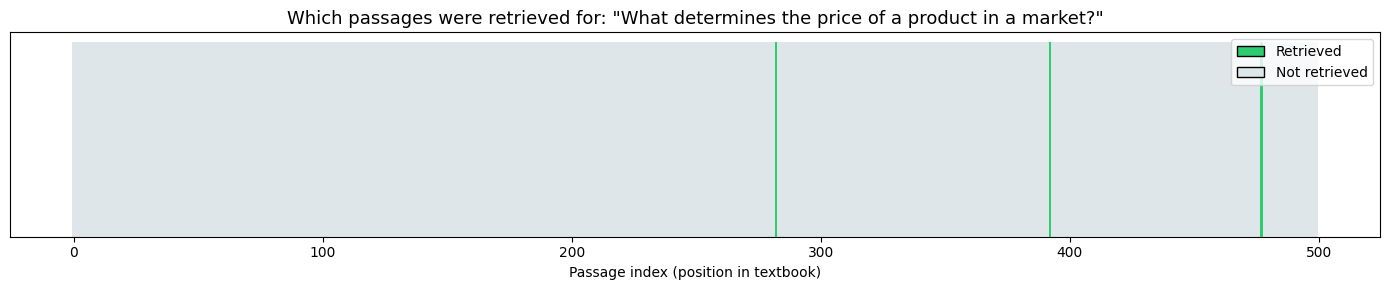

Each bar is one textbook passage. The green ones are what the search found as most relevant.
Notice they can come from anywhere in the textbook — the search is by meaning, not by position.


In [31]:
# Visualize which chunks were retrieved out of all 500
retrieved_indices = set(r["index"] for r in results)

fig, ax = plt.subplots(figsize=(14, 3))

bar_colors = ["#2ecc71" if i in retrieved_indices else "#dfe6e9" for i in range(len(chunks))]

ax.bar(range(len(chunks)), [1] * len(chunks), color=bar_colors, edgecolor="none", width=1.0)
ax.set_title(f'Which passages were retrieved for: "{question}"', fontsize=13)
ax.set_xlabel("Passage index (position in textbook)")
ax.set_yticks([])

legend_elements = [
    Patch(facecolor="#2ecc71", edgecolor="black", label="Retrieved"),
    Patch(facecolor="#dfe6e9", edgecolor="black", label="Not retrieved")
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

print("Each bar is one textbook passage. The green ones are what the search found as most relevant.")
print("Notice they can come from anywhere in the textbook — the search is by meaning, not by position.")

---
## With vs. Without the Textbook

Same question, two approaches:
- **Without RAG** = closed-book exam (model guesses from memory)
- **With RAG** = open-book exam (model reads the textbook first)

We ask **specific, pointed questions** that demand concrete facts — not broad questions where the model can hide behind bullet points.

In [32]:
# Load the language model
model_path = os.path.join(os.getcwd(), "models")

model = Llama(
    model_path=os.path.join(model_path, "qwen2-1_5b-instruct-q4_0.gguf"),
    n_ctx=2048,
    verbose=False,
    chat_format="chatml"
)
print("Model loaded!")

llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kernel_mul_mv_id_bf16_f32                (not supported)
ggml_metal_init: skipping kernel_mul_mm_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mm_id_bf16_f16                (not supported)
ggml_metal_init: skipping kernel_flash_attn_ext_bf16_h64 

Model loaded!


In [33]:
def ask_with_rag(question, n_chunks=3):
    """Retrieve textbook passages, then generate an answer."""
    results = search_textbook(question, n_results=n_chunks)
    retrieved_texts = [r["text"] for r in results]

    context = "\n\n".join(retrieved_texts)
    prompt = f"""Answer the question in 1-2 sentences using the textbook passages below.
Include specific details and numbers from the passages.

Textbook passages:
{context}

Question: {question}

Answer (1-2 sentences):"""

    response = model.create_chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=150
    )
    return response["choices"][0]["message"]["content"], results


def ask_without_rag(question):
    """Ask the model directly — no textbook, just its own knowledge."""
    prompt = f"Answer in 1-2 sentences: {question}"
    response = model.create_chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=150
    )
    return response["choices"][0]["message"]["content"]

print("Functions defined!")

Functions defined!


In [34]:
# Pointed question: demands a specific number the model can't guess
test_question = "What was the world price of coffee per pound in 1993?"

answer_no_rag = ask_without_rag(test_question)
answer_rag, rag_results = ask_with_rag(test_question)

print("=" * 60)
print(f'Question: "{test_question}"')
print("=" * 60)
print()
print("WITHOUT RAG (closed-book — model guesses):")
print("-" * 60)
print(answer_no_rag)
print()
print("WITH RAG (open-book — model reads the textbook):")
print("-" * 60)
print(answer_rag)

# Fact check
print()
print("FACT CHECK — the textbook says:")
print("-" * 60)
for r in rag_results:
    if "1993" in r["text"] or "50 cents" in r["text"]:
        print(f"  {r['text'][:400].replace(chr(10), ' ')}")
        break
else:
    print(f"  {rag_results[0]['text'][:400].replace(chr(10), ' ')}")

Question: "What was the world price of coffee per pound in 1993?"

WITHOUT RAG (closed-book — model guesses):
------------------------------------------------------------
The world price of coffee per pound in 1993 was approximately $1.20.

WITH RAG (open-book — model reads the textbook):
------------------------------------------------------------
The world price of coffee per pound was about 50 cents in 1993.

FACT CHECK — the textbook says:
------------------------------------------------------------
  income. These families are exposed to enormous risk, because the world price of coffee bounces up and down. For  example, in 1993, the world price of coffee was about 50 cents per pound. In 1995 it was four times as high, at $2  per pound. By 1997 it had fallen by half to $1.00 per pound. In 1998 it leaped back up to $2 per pound. By 2001 it  had fallen back to 46 cents a pound. By early 2011 it r


Without RAG, the model either refuses or invents a number. With RAG, it gives the exact price. **The question isn't which answer is longer — it's which one is right.**

In [35]:
# Another pointed question — different fact, same pattern
hard_question = "In what year did a major frost hit the Brazilian coffee crop?"

answer_no_rag_2 = ask_without_rag(hard_question)
answer_rag_2, rag_results_2 = ask_with_rag(hard_question)

print("=" * 60)
print(f'Question: "{hard_question}"')
print("=" * 60)
print()
print("WITHOUT RAG (closed-book):")
print("-" * 60)
print(answer_no_rag_2)
print()
print("WITH RAG (open-book):")
print("-" * 60)
print(answer_rag_2)

# Fact check
print()
print("FACT CHECK — the textbook says:")
print("-" * 60)
for r in rag_results_2:
    if "frost" in r["text"].lower() or "1994" in r["text"]:
        print(f"  {r['text'][:400].replace(chr(10), ' ')}")
        break
else:
    print(f"  {rag_results_2[0]['text'][:400].replace(chr(10), ' ')}")

Question: "In what year did a major frost hit the Brazilian coffee crop?"

WITHOUT RAG (closed-book):
------------------------------------------------------------
A major frost hit the Brazilian coffee crop in the year 1886.

WITH RAG (open-book):
------------------------------------------------------------
In 1994, a major frost hit the Brazilian coffee crop, leading to a shift in the coffee supply curve to the left, causing an increase in the price of coffee.

FACT CHECK — the textbook says:
------------------------------------------------------------
  government direction or oversight. If the coffee crop in Brazil suffers a terrible frost, then the supply curve of  coffee shifts to the left and the price of coffee rises. Some people continue to drink coffee and pay the higher  price. Others switch to tea or soft drinks. No government commission is needed to figure out how to adjust  coffee prices, which companies will be allowed to process the 


---
## Does More Context Help?

We can control how many passages to retrieve. Let's compare **1 passage vs. 3 passages** for the same question.

In [36]:
context_question = "What happens when the government sets a price floor?"

answer_1, results_1 = ask_with_rag(context_question, n_chunks=1)
answer_3, results_3 = ask_with_rag(context_question, n_chunks=3)

print("=" * 60)
print(f'Question: "{context_question}"')
print("=" * 60)
print()
print("WITH 1 PASSAGE:")
print(f"  Retrieved: chunk {results_1[0]['index']} (similarity {results_1[0]['similarity']:.3f})")
print(f"  Answer: {answer_1}")
print()
print("WITH 3 PASSAGES:")
for r in results_3:
    print(f"  Retrieved: chunk {r['index']} (similarity {r['similarity']:.3f})")
print(f"  Answer: {answer_3}")

Question: "What happens when the government sets a price floor?"

WITH 1 PASSAGE:
  Retrieved: chunk 173 (similarity 0.580)
  Answer: When the government sets a price floor, it keeps the price of some necessary good or service affordable. For example, in 2005 during Hurricane Katrina, the price of bottled water increased above $5 per gallon, and many people called for a price floor to keep the price affordable.

WITH 3 PASSAGES:
  Retrieved: chunk 173 (similarity 0.580)
  Retrieved: chunk 172 (similarity 0.569)
  Retrieved: chunk 190 (similarity 0.565)
  Answer: A price floor is a legal minimum price that one pays for some good or service. When the government sets a price floor, it transfers some consumer surplus to producers, which explains why producers often favor them. However, both price floors and price ceilings block some transactions that buyers and sellers would have been willing to make, and creates deadweight loss. Removing such barriers, so that prices and quantities can ad

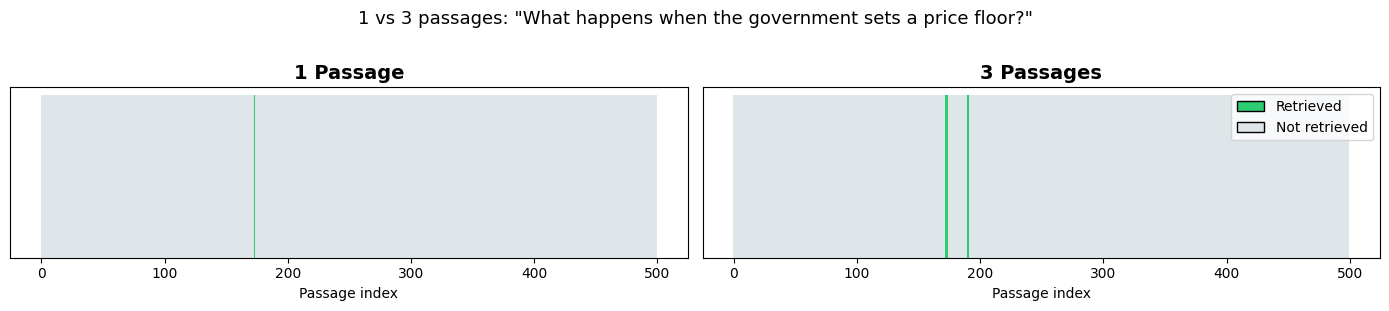

In [37]:
# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

for ax, res, label in [(axes[0], results_1, "1 Passage"), (axes[1], results_3, "3 Passages")]:
    id_set = set(r["index"] for r in res)
    bar_colors = ["#2ecc71" if i in id_set else "#dfe6e9" for i in range(len(chunks))]
    ax.bar(range(len(chunks)), [1] * len(chunks), color=bar_colors, edgecolor="none", width=1.0)
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xlabel("Passage index")
    ax.set_yticks([])

legend_elements = [
    Patch(facecolor="#2ecc71", edgecolor="black", label="Retrieved"),
    Patch(facecolor="#dfe6e9", edgecolor="black", label="Not retrieved")
]
axes[1].legend(handles=legend_elements, loc="upper right")

plt.suptitle(f'1 vs 3 passages: "{context_question}"', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

More passages = more information, but too many can confuse a small model or hit the context window limit. 3 chunks is a good default.

---
## The Full Pipeline

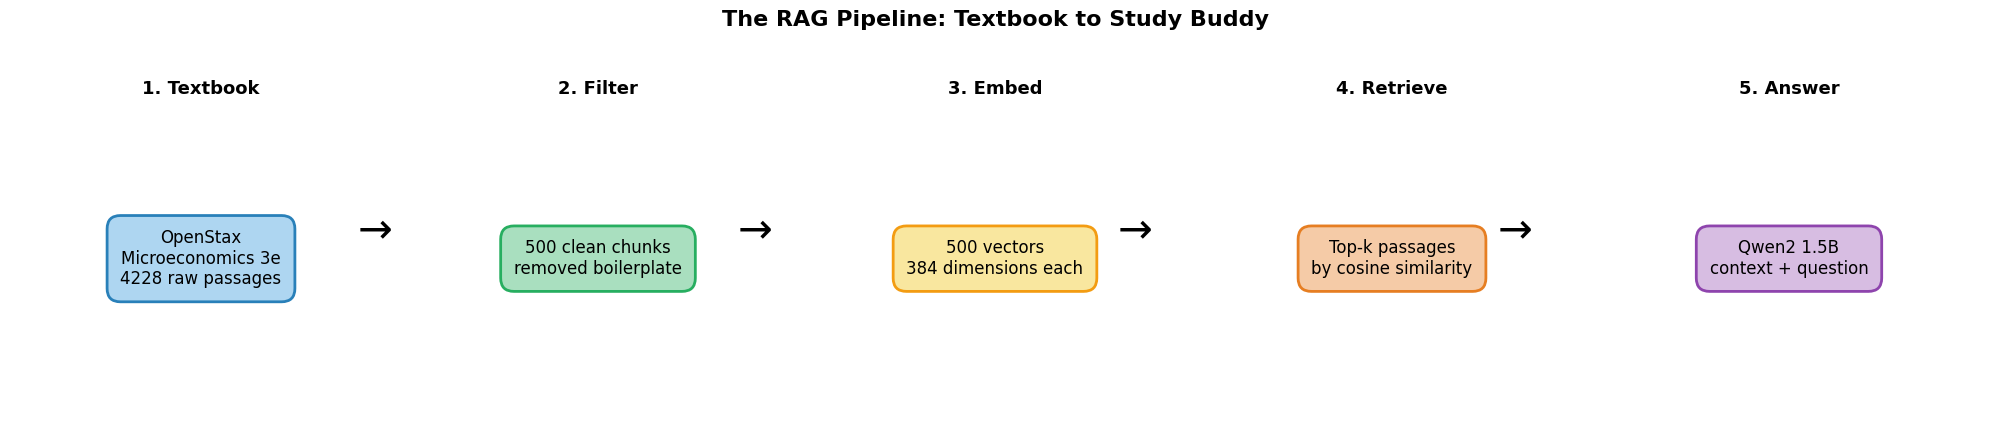

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

panels = [
    ("1. Textbook", f"OpenStax\nMicroeconomics 3e\n{len(ds)} raw passages", "#AED6F1", "#2980B9"),
    ("2. Filter", f"{len(chunks)} clean chunks\nremoved boilerplate", "#A9DFBF", "#27AE60"),
    ("3. Embed", f"{chunk_embeddings.shape[0]} vectors\n{chunk_embeddings.shape[1]} dimensions each", "#F9E79F", "#F39C12"),
    ("4. Retrieve", f"Top-k passages\nby cosine similarity", "#F5CBA7", "#E67E22"),
    ("5. Answer", f"Qwen2 1.5B\ncontext + question", "#D7BDE2", "#8E44AD"),
]

for ax, (title, text, facecolor, edgecolor) in zip(axes, panels):
    ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.8", facecolor=facecolor,
                      edgecolor=edgecolor, linewidth=2),
            transform=ax.transAxes)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

for i in range(4):
    fig.text(0.19 + i * 0.19, 0.5, "\u2192", fontsize=30, ha="center", va="center")

plt.suptitle("The RAG Pipeline: Textbook to Study Buddy", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

---
## Try It Yourself!

Change the question below. **The more specific, the better RAG works:**

- `"How much did the price of coffee fall to per pound by 2001?"`
- `"What was the world price of coffee per pound in 1998?"`
- `"How does a perfectly competitive firm decide what quantity to produce?"`
- `"What is the relationship between elasticity and total revenue?"`

Your question: "How much did the price of coffee fall to per pound by 2001?"

WITHOUT textbook:
------------------------------------------------------------
The price of coffee fell to approximately $0.10 per pound by 2001, according to the World Bank.

WITH textbook (RAG):
------------------------------------------------------------
By 2001, the price of coffee had fallen back to $1.31 per pound.

FACT CHECK — the textbook says:
------------------------------------------------------------
  income. These families are exposed to enormous risk, because the world price of coffee bounces up and down. For  example, in 1993, the world price of coffee was about 50 cents per pound. In 1995 it was four times as high, at $2  per pound. By 1997 it had fallen by half to $1.00 per pound. In 1998 it leaped back up to $2 per pound. By 2001 it  had fallen back to 46 cents a pound. By early 2011 it r


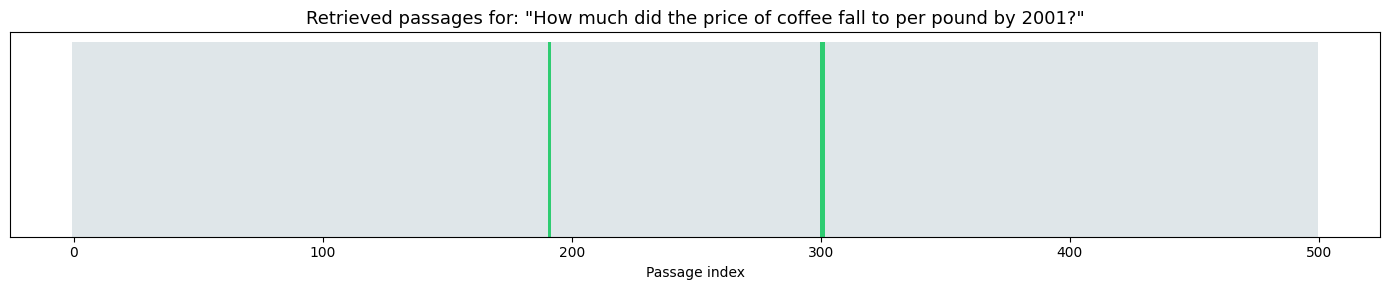

In [39]:
# CHANGE THIS QUESTION!
my_question = "How much did the price of coffee fall to per pound by 2001?"

my_no_rag = ask_without_rag(my_question)
my_rag, my_results = ask_with_rag(my_question, n_chunks=3)

print("=" * 60)
print(f'Your question: "{my_question}"')
print("=" * 60)
print()
print("WITHOUT textbook:")
print("-" * 60)
print(my_no_rag)
print()
print("WITH textbook (RAG):")
print("-" * 60)
print(my_rag)
print()
print("FACT CHECK — the textbook says:")
print("-" * 60)
print(f"  {my_results[0]['text'][:400].replace(chr(10), ' ')}")

# Visualize retrieval
fig, ax = plt.subplots(figsize=(14, 3))
retrieved_set = set(r["index"] for r in my_results)
bar_colors = ["#2ecc71" if i in retrieved_set else "#dfe6e9" for i in range(len(chunks))]
ax.bar(range(len(chunks)), [1] * len(chunks), color=bar_colors, edgecolor="none", width=1.0)
ax.set_title(f'Retrieved passages for: "{my_question}"', fontsize=13)
ax.set_xlabel("Passage index")
ax.set_yticks([])
plt.tight_layout()
plt.show()

---
## RAG Isn't Perfect — and That's the Point

You may notice that even **with** the textbook passage in front of it, the model sometimes gets facts wrong — misquoting a number or mixing up details. That's not a bug in RAG. It reveals an important distinction:

A RAG pipeline has **two parts that can each fail independently:**

| Step | What it does | What can go wrong |
|------|-------------|-------------------|
| **Retrieval** | Find the right passage | Wrong passage retrieved (bad embeddings, bad query) |
| **Generation** | Read the passage and answer | Model misreads or hallucinates despite having the right text |

Our 1.5B parameter model is small — it sometimes struggles to extract the right detail from a passage, even when the answer is right there. A larger model (7B, 70B, or a cloud API like GPT-4) would do better at the generation step. But the **retrieval** step works the same regardless of model size — that's the part we built in this notebook.

---
## Summary

| What | How |
|------|-----|
| **Data** | OpenStax Microeconomics 3e, loaded from Hugging Face |
| **Vector store** | Embeddings (numpy arrays) + cosine similarity search |
| **Why RAG matters** | A small model + the right passage beats a larger model guessing |
| **Pipeline** | Textbook → Filter → Embed → Search → Generate |

---

**The RAG series:**
- **Part 1** (Pipeline Visualizer): Word matching + basic RAG concept
- **Part 2** (Embeddings Visualizer): Semantic similarity with embeddings
- **Part 3** (Vector Store): Real textbook + study buddy